In [23]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# Atualizar funções automaticamente dentro do notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
#Standard imports

import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

In [25]:
sns.set()
# ?

# Carregando Dados

```
def my_function():
    print("Hello world")
```

In [4]:
data = datasets.load_iris()

In [5]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [97]:
# print(data["DESCR"])

In [7]:
data['data'][:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [8]:
data['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [9]:
data['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [10]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## Qual problema estamos tentando resolver?

Classicar as flores a partir da altura e largura da petala e da sepala em seu respectivo grupo: Setosa, Versicolor ou Virginica. Vamos ensinar o modelo vai aprender a classficar as flores, em sua classe correta.

Problema de classificção multiclasse.

In [96]:
# pd.DataFrame?

In [12]:
df = pd.DataFrame(data['data'], columns = data['feature_names']) 

In [13]:
df['target'] = data['target']

In [14]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Estatistica Descritiva Básica

In [15]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


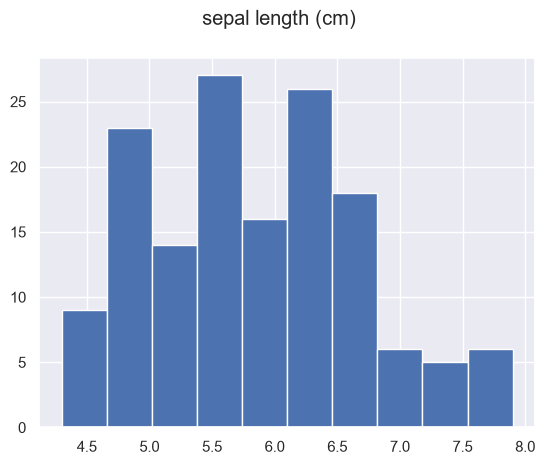

In [16]:
col = 'sepal length (cm)'
df[col].hist()
plt.suptitle(col)
plt.show()

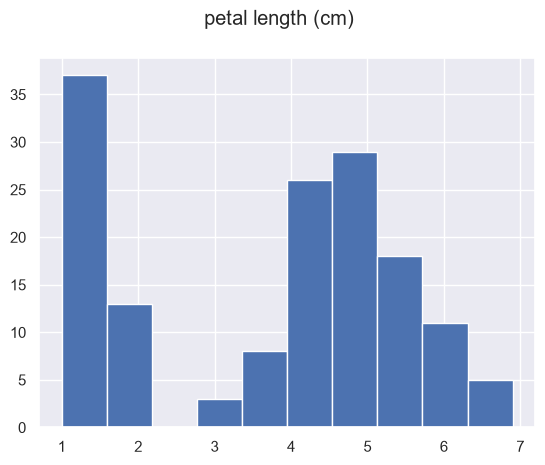

In [17]:
col = 'petal length (cm)'
df[col].hist()
plt.suptitle(col)
plt.show()

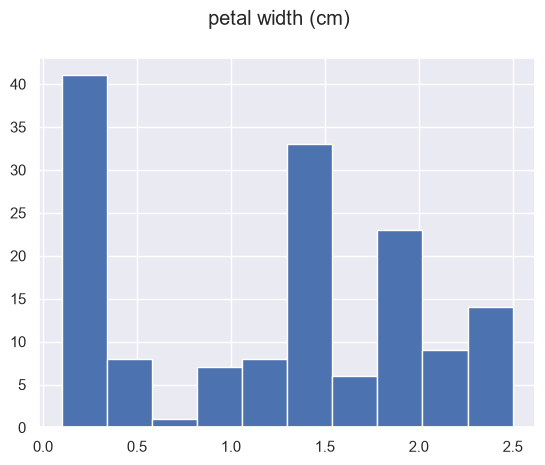

In [18]:
col = 'petal width (cm)'
df[col].hist()
plt.suptitle(col)
plt.show()

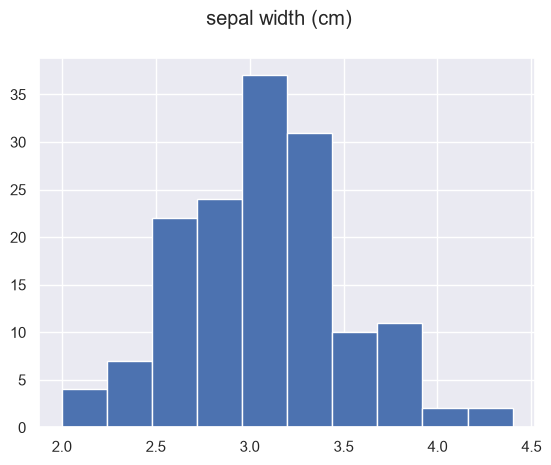

In [19]:
col = 'sepal width (cm)'
df[col].hist()
plt.suptitle(col)
plt.show()

# Relação das caracteristicas dos dados com o alvo

In [20]:
data['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [21]:
# Criando nova coluna com o nome das espécies.
df['target_name'] = df['target'].map({0:"setosa", 1: 'versicolor', 2:'virginica'})

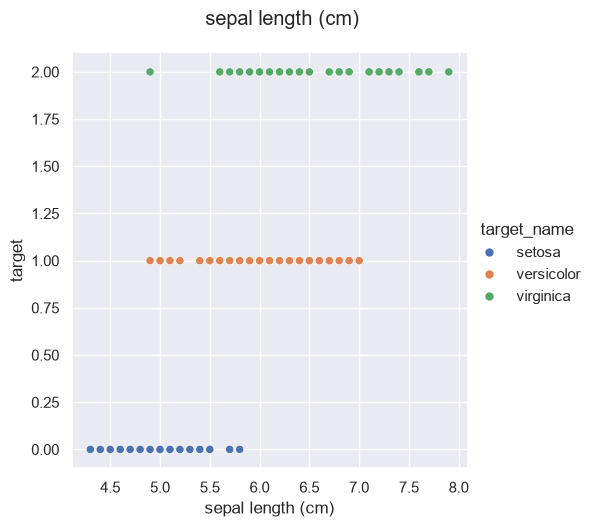

In [29]:
col = 'sepal length (cm)'

sns.relplot(x=col, y='target', hue='target_name', data=df)
plt.suptitle(col, y=1.05)
plt.show()

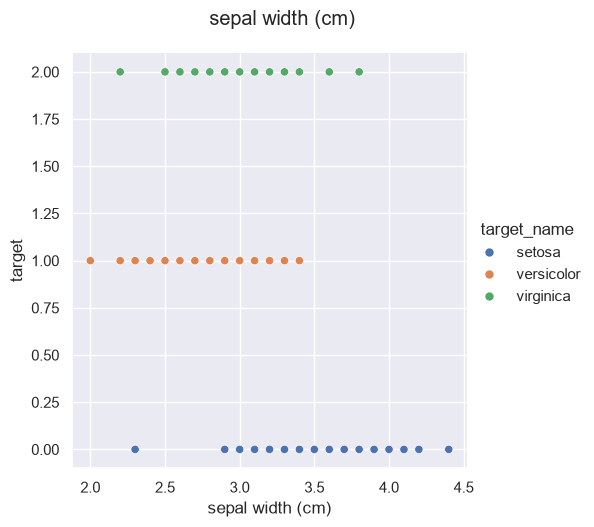

In [31]:
col = 'sepal width (cm)'

sns.relplot(x=col, y='target', hue='target_name', data=df)
plt.suptitle(col, y=1.05)
plt.show()

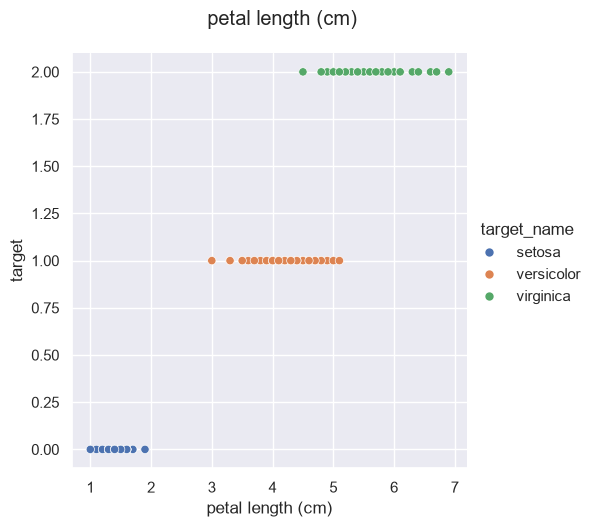

In [32]:
col = 'petal length (cm)'

sns.relplot(x=col, y='target', hue='target_name', data=df)
plt.suptitle(col, y=1.05)
plt.show()

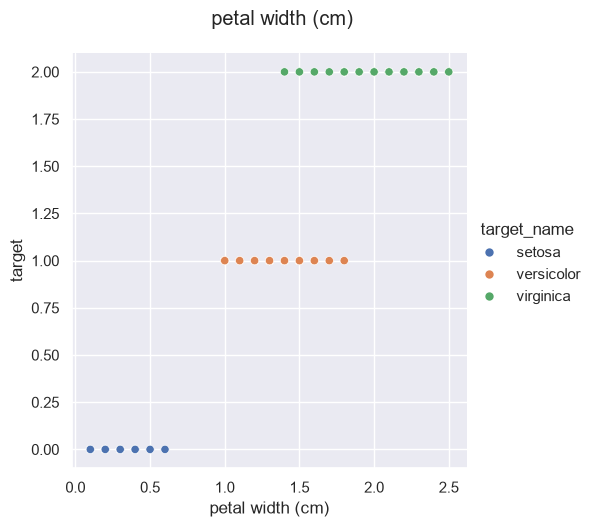

In [33]:
col = 'petal width (cm)'

sns.relplot(x=col, y='target', hue='target_name', data=df)
plt.suptitle(col, y=1.05)
plt.show()

# EDA - Exploratory Data Analysis
## Plot em Pares

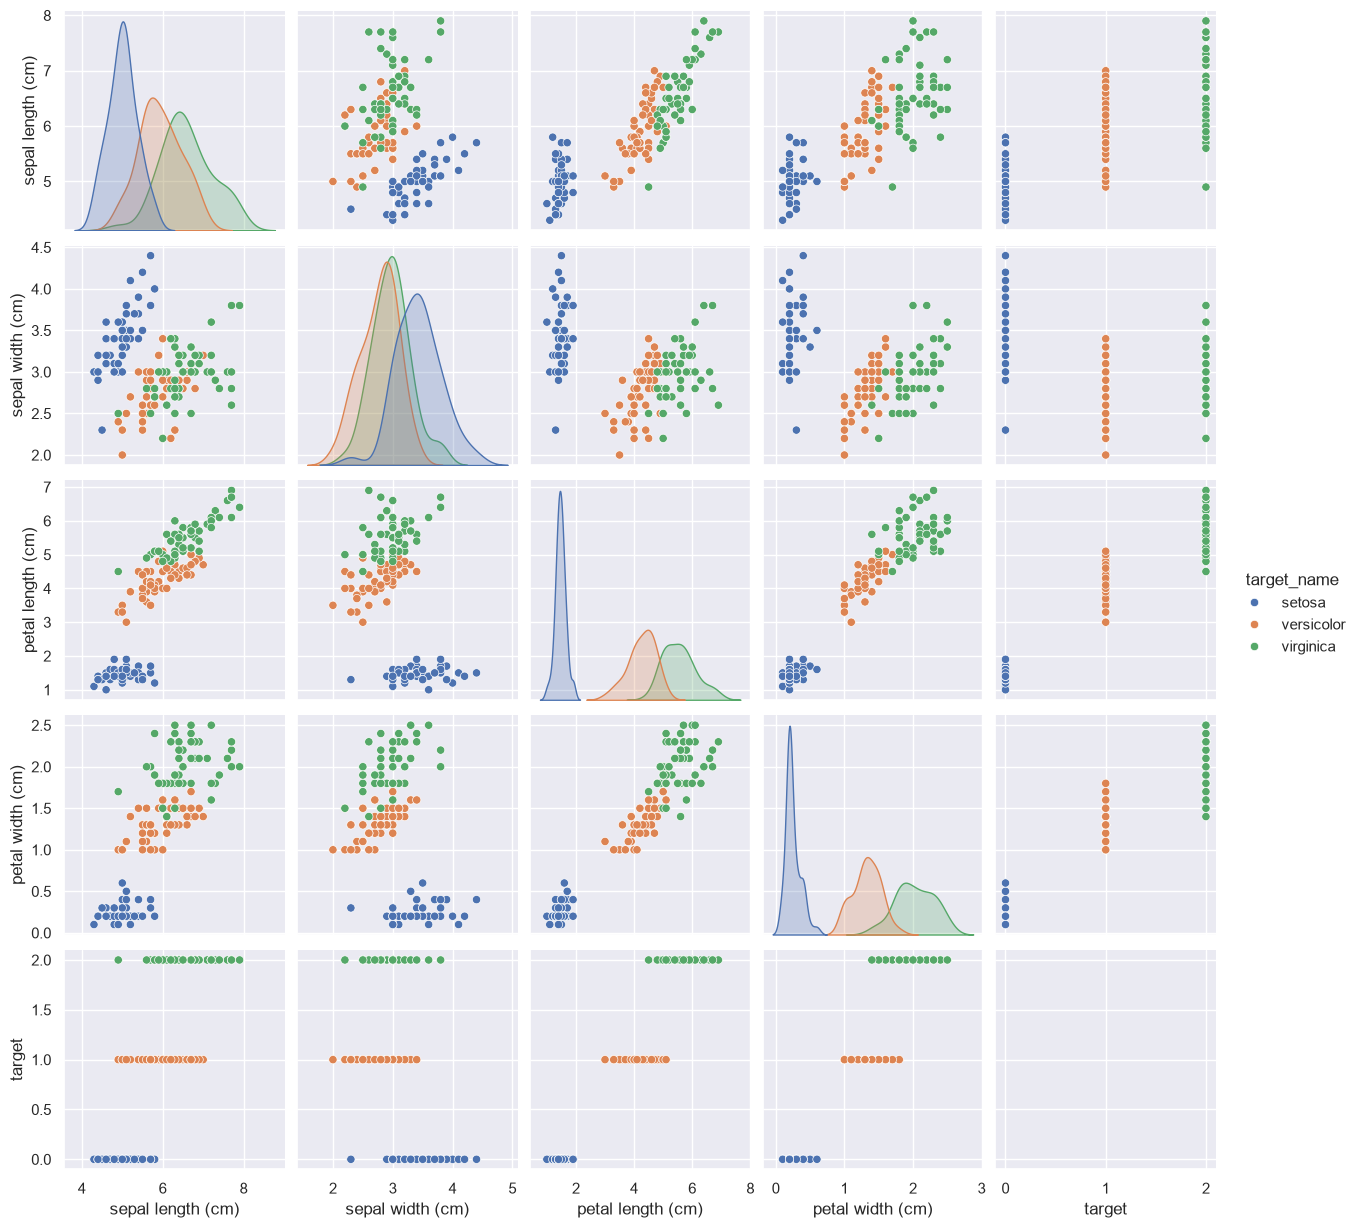

In [36]:
sns.pairplot(df, hue="target_name")

# Separar dados de treino e teste
Para medir a acuracia final do modelo sempre vamos usar um conjuto de dados separado do conjunto que foi utilizado no treino. <br>
VER: Validação Cruzada

In [37]:
from sklearn.model_selection import train_test_split

In [39]:
df_train, df_test = train_test_split(df, test_size=0.20)

In [40]:
df_train.shape

(120, 6)

In [41]:
df_test.shape

(30, 6)

In [42]:
df_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
4,5.0,3.6,1.4,0.2,0,setosa
69,5.6,2.5,3.9,1.1,1,versicolor
90,5.5,2.6,4.4,1.2,1,versicolor
115,6.4,3.2,5.3,2.3,2,virginica
144,6.7,3.3,5.7,2.5,2,virginica


# Preparando dados para aplicar o Modelo

In [50]:
x_train = df_train.drop(columns=['target', 'target_name']).values
y_train = df_train['target'].values

In [51]:
y_train

array([0, 1, 1, 2, 2, 0, 2, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 2, 2, 1, 1, 1,
       2, 2, 1, 0, 0, 1, 0, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 0, 1, 0, 1, 1,
       2, 2, 0, 0, 1, 1, 2, 1, 0, 1, 2, 1, 2, 2, 0, 0, 2, 2, 2, 0, 0, 2,
       0, 1, 2, 2, 2, 1, 0, 1, 0, 1, 0, 2, 0, 0, 2, 0, 2, 2, 0, 1, 1, 1,
       0, 1, 0, 1, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 2, 2,
       0, 1, 1, 1, 2, 0, 1, 0, 0, 0])

# Modelo - Qual a nossa base?

Qual o resultado devemos alcançar ? <br>
Classificando o modelo da flor no chute seria 1/3 = 33,33% de acerto. <br>
Como o modelo é balanceado, com a mesma quantidade de flores para cada classificação, então devemos esperar que o modelo tenha mais do que 33% de acuracia.

# Modelo - Regras simples

In [66]:
def predicao_simples(petal_length):
    """ Prevê a especie pelo comprimento da petala. """
    if petal_length < 2.5: # Setosa
        return 0
    elif petal_length < 4.8: # Versicolor
        return 1
    else:  # Virginica
        return 2

In [67]:
df_train.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'target_name'],
      dtype='str')

In [68]:
x_train[:, 2]

array([1.4, 3.9, 4.4, 5.3, 5.7, 1.5, 5.6, 4.1, 1.4, 5.6, 3.5, 5.8, 1.4,
       5.3, 1.4, 3.6, 6.1, 5.6, 5.6, 4.4, 5. , 4.7, 6.6, 5.1, 4. , 1.4,
       1.4, 4.6, 1.5, 1.4, 1.5, 5.6, 5.1, 6.7, 4.7, 5.1, 1.9, 5.1, 4.4,
       1.3, 4. , 1.7, 4.7, 5.1, 5.2, 5.7, 1.6, 1.4, 4.7, 3.5, 6.4, 4.1,
       1.3, 4.6, 6.1, 3.7, 4.8, 6.1, 1. , 1.7, 5.8, 5.7, 5.4, 1.2, 1.5,
       5.5, 1.5, 3.8, 6. , 5.6, 4.9, 4.2, 1.3, 4.7, 1.6, 4.5, 1.5, 5.5,
       1.6, 1.5, 6.9, 1.4, 4.8, 4.9, 1.3, 4.2, 3.9, 4.8, 1.4, 4.8, 1.2,
       4. , 6. , 5.9, 4.5, 1.5, 1.5, 1.6, 1.5, 4.3, 3.3, 1.3, 4.5, 1.5,
       4. , 4.3, 1.4, 4. , 5.1, 5. , 1.1, 3. , 4.1, 4.5, 5. , 1.6, 4.5,
       1.4, 1.3, 1.5])

In [69]:
df_train["petal length (cm)"].values

array([1.4, 3.9, 4.4, 5.3, 5.7, 1.5, 5.6, 4.1, 1.4, 5.6, 3.5, 5.8, 1.4,
       5.3, 1.4, 3.6, 6.1, 5.6, 5.6, 4.4, 5. , 4.7, 6.6, 5.1, 4. , 1.4,
       1.4, 4.6, 1.5, 1.4, 1.5, 5.6, 5.1, 6.7, 4.7, 5.1, 1.9, 5.1, 4.4,
       1.3, 4. , 1.7, 4.7, 5.1, 5.2, 5.7, 1.6, 1.4, 4.7, 3.5, 6.4, 4.1,
       1.3, 4.6, 6.1, 3.7, 4.8, 6.1, 1. , 1.7, 5.8, 5.7, 5.4, 1.2, 1.5,
       5.5, 1.5, 3.8, 6. , 5.6, 4.9, 4.2, 1.3, 4.7, 1.6, 4.5, 1.5, 5.5,
       1.6, 1.5, 6.9, 1.4, 4.8, 4.9, 1.3, 4.2, 3.9, 4.8, 1.4, 4.8, 1.2,
       4. , 6. , 5.9, 4.5, 1.5, 1.5, 1.6, 1.5, 4.3, 3.3, 1.3, 4.5, 1.5,
       4. , 4.3, 1.4, 4. , 5.1, 5. , 1.1, 3. , 4.1, 4.5, 5. , 1.6, 4.5,
       1.4, 1.3, 1.5])

In [76]:
result_predicao_manual = np.array([predicao_simples(val) for val in x_train[:, 2]])

In [88]:
acuracia_modelo_manual = np.mean(result_predicao_manual == y_train)
print(f'Acuracia do Modelo Manual: {acuracia_modelo_manual * 100:.2f}%')

Acuracia do Modelo Manual: 95.83%


# Modelo - Regressão Logistica

In [89]:
from sklearn.linear_model import LogisticRegression

In [162]:
Xt, Xv, yt, yv = train_test_split(x_train, y_train, test_size=0.2, random_state=50, stratify=y_train)
# t = treino
# v = validação

In [119]:
Xt.shape

(96, 4)

In [120]:
Xv.shape

(24, 4)

In [163]:
model = LogisticRegression()

In [164]:
model.fit(Xt, yt)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [165]:
y_pred = model.predict(Xv)

In [166]:
y_predicao = np.mean(y_pred == yv)

print(y_predicao)

# 0.875

0.9583333333333334


In [167]:
model.score(x_train, y_train)

0.9833333333333333

In [ ]:
# Modelo dele: 0.964

# Descobertas

+ Divisão de treino e teste em 80/20. Mas como saber se essa é a melhor ? Geralmente é o padrão mas esse conjunto de dados é muito pequeno.
+ Diferente do cara do video eu dividi em 80/20 ele dividiu em 80/25 e obeteve resultados melhores na validação do modelo tanto treino quanto teste.
+ Adicionei random_state e o stratify <br>
random_state: Congela o embaralhamento dos dados. Garante que o código dê sempre o mesmo resultado toda vez que você o executa.<br>
stratify: Mantém a proporção original das classes idêntica tanto no treino quanto no teste, evitando que uma categoria fique de fora de um dos lados.<br>
+ Mesmo assim meus resultados ainda estãpo inferiores ao dele.
+ Estudar como fazer a melhor escolha de parametros e divisão dos dado e por que 80/20 não foi uma boa escolha para esse exemplo
+ Entender linha a linha do código.

# Usando validação cruzada para validar nosso modelo


In [168]:
from sklearn.model_selection import cross_val_score, cross_val_predict

In [169]:
model = LogisticRegression(max_iter=200)

In [171]:
accuracies = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')

In [172]:
np.mean(accuracies)   # a dele : 0.97

np.float64(0.95)

# Onde estamos classificando incorretamente?

In [173]:
y_pred = cross_val_predict(model, x_train, y_train, cv=5)

In [178]:
predicao_correta_mask = y_pred == y_train 
# Meu modelo possui o dobro de erros do dele, o dele deu 3 Falses verificar

In [182]:
nao_previsto_corretamente = ~predicao_correta_mask

In [179]:
x_train[~predicao_correta_mask # Se olha por linha

array([[6.7, 3. , 5. , 1.7],
       [6. , 2.7, 5.1, 1.6],
       [6. , 3. , 4.8, 1.8],
       [5.9, 3.2, 4.8, 1.8],
       [4.9, 2.5, 4.5, 1.7],
       [6. , 2.2, 5. , 1.5]])

In [183]:
df_predicoes = df_train.copy()

In [185]:
df_predicoes['predicao_correta'] =  predicao_correta_mask

In [186]:
df_predicoes['predicao'] = y_pred

In [187]:
df_predicoes['predicao_label'] = df_predicoes['predicao'].map({0: 'setosa', 1:'versicolor', 2: 'virginica'})

In [188]:
df_predicoes.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name,predicao_correta,predicao,predicao_label
4,5.0,3.6,1.4,0.2,0,setosa,True,0,setosa
69,5.6,2.5,3.9,1.1,1,versicolor,True,1,versicolor
90,5.5,2.6,4.4,1.2,1,versicolor,True,1,versicolor
115,6.4,3.2,5.3,2.3,2,virginica,True,2,virginica
144,6.7,3.3,5.7,2.5,2,virginica,True,2,virginica


<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

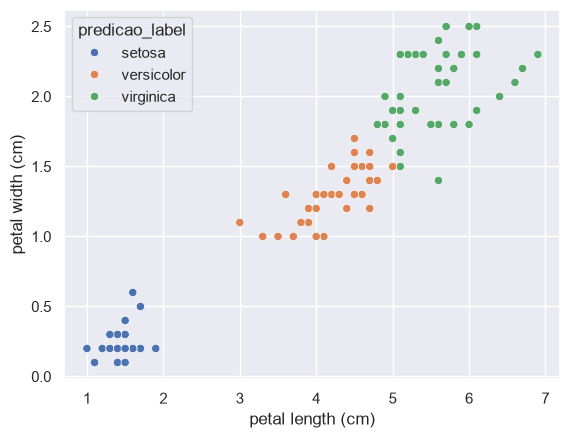

In [191]:
sns.scatterplot(x= 'petal length (cm)', y= 'petal width (cm)', hue = 'predicao_label', data = df_predicoes  )

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

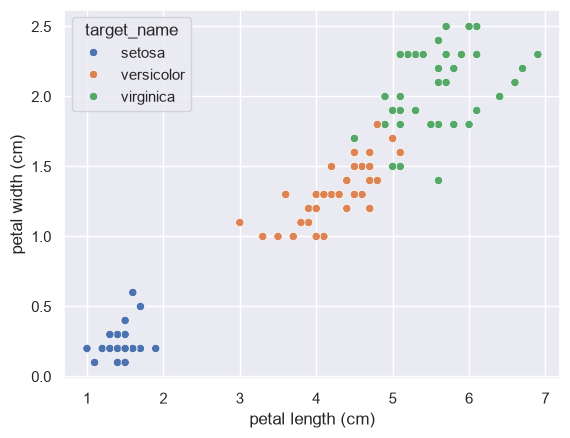

In [194]:
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='target_name', data=df_predicoes)

In [218]:
def plot_previsoes_incorretas(df_predicoes, x_axis_feature, y_axis_feature):
    fig, axs = plt.subplots(1,3, figsize=(15, 5))
    axs = axs.flatten()
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue='predicao_label', data=df_predicoes, ax=axs[0])
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue='target_name', data=df_predicoes, ax=axs[1])
    sns.scatterplot(x=x_axis_feature, y=y_axis_feature, hue='predicao_correta', data=df_predicoes, ax=axs[2])

    
    plt.show()

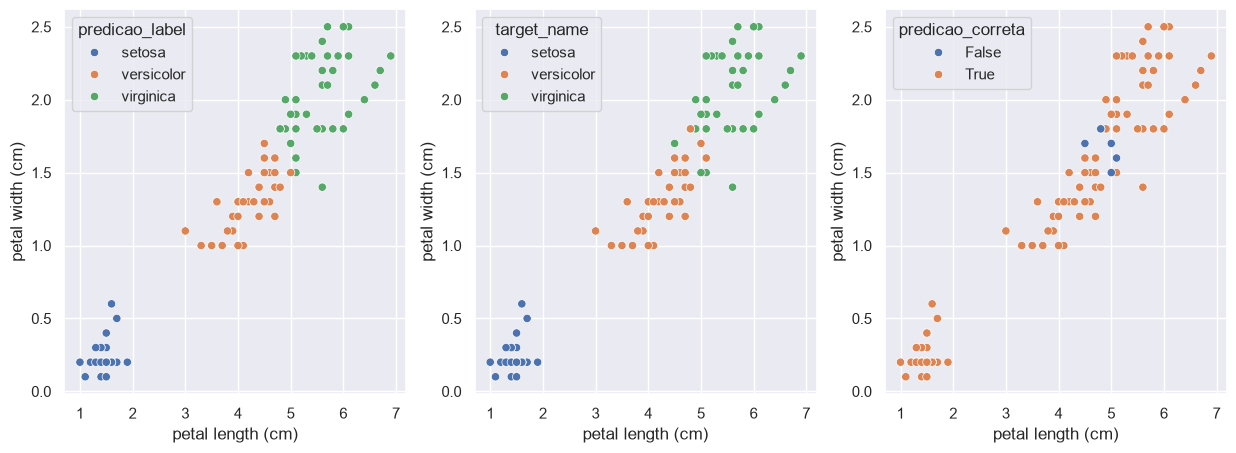

In [219]:
plot_previsoes_incorretas(df_predicoes, 'petal length (cm)', 'petal width (cm)')

# Refinamento (Model Tuning)

## O que é? 
Tentar determ,inar os parametros do seu modelo (hiperparametros) que maximizem a performance do modelo.

In [259]:
for reg_param in (1, 1.2, 1.5, 2, 3, 4, 5):
    print(reg_param)
    model = LogisticRegression(max_iter=200, C=reg_param)
    acuracias = cross_val_score(model, x_train, y_train, cv=5, scoring="accuracy")
    print(np.mean(acuracias))

1
0.95
1.2
0.95
1.5
0.95
2
0.95
3
0.95
4
0.95
5
0.95


# Modelo Final

In [267]:
model = LogisticRegression(max_iter=200, C=2)

# Quão bem nosso modelo desempenha no conjunto de teste?

In [261]:
x_test = df_test.drop(columns = {'target', 'target_name'}).values
y_test = df_test['target'].values

In [247]:
x_test.shape

(30, 4)

In [262]:
y_test

array([0, 2, 1, 0, 0, 2, 2, 2, 2, 1, 0, 1, 0, 2, 1, 1, 1, 1, 2, 2, 0, 1,
       0, 1, 2, 0, 1, 2, 2, 1])

# Treinando nosso modelo final usando todo o Dataset de treino

In [263]:
model.fit(x_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",200
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [264]:
y_test_pred = model.predict(x_test)

In [265]:
test_set_correto_class = y_test_pred == y_test
test_set_accuracy = np.mean(test_set_correto_class)

In [266]:
print(f'Teste Acuracia: {test_set_accuracy *100:.2f}') # o dele deu 94.74

Teste Acuracia: 100.00


# Parabens!! Você fez um Overfitting

Literalmente com o pode em todo o tempo meu modelo ter perfomado pior que o dele nos treinos e na hora do teste performar pior que o dele e depois na hora do teste ele dar overfitting?

In [276]:
df_predicoes_test = df_test.copy()
df_predicoes_test['predicao_correta'] = test_set_correto_class
df_predicoes_test['prediction'] = y_test_pred 
df_predicoes_test['predicao_label'] = df_predicoes_test['prediction'].map({0: 'setosa', 1:'versicolor', 2: 'virginica'})

In [277]:
df_predicoes_test.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name,predicao_correta,prediction,predicao_label
16,5.4,3.9,1.3,0.4,0,setosa,True,0,setosa
123,6.3,2.7,4.9,1.8,2,virginica,True,2,virginica
94,5.6,2.7,4.2,1.3,1,versicolor,True,1,versicolor
26,5.0,3.4,1.6,0.4,0,setosa,True,0,setosa
44,5.1,3.8,1.9,0.4,0,setosa,True,0,setosa


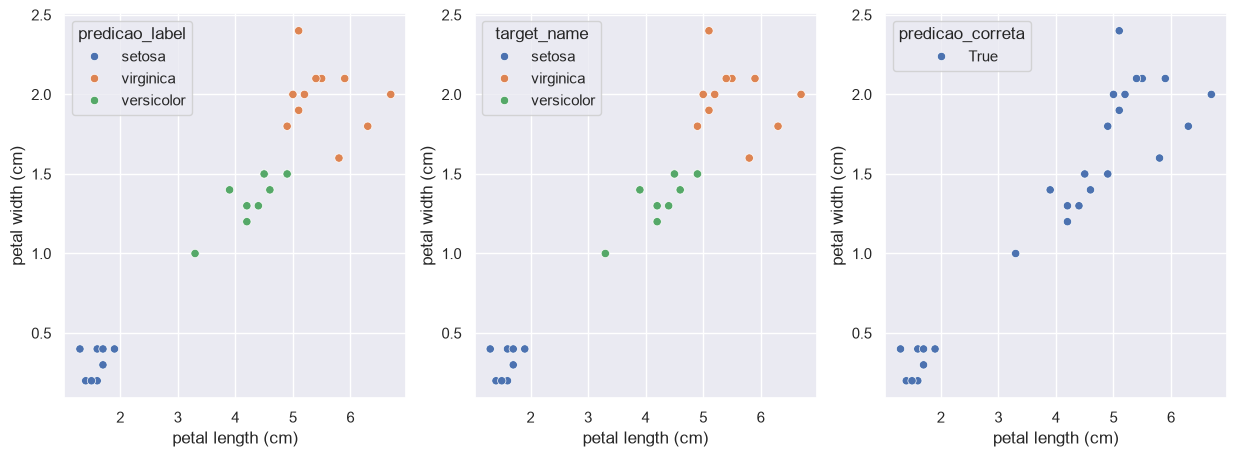

In [278]:
plot_previsoes_incorretas(df_predicoes_test, x_axis_feature='petal length (cm)', y_axis_feature='petal width (cm)')

# Conclusão:

* Arrumar o overfitting

* Parametros

  ```
  
  ```